In [9]:
# from libraries import *
from scenario import Scenario
import numpy as np
# import matplotlib as plt
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [10]:
scene = Scenario()
rnd_policy = np.ones((scene.states.n, scene.actions.n)) / scene.actions.n
print(f'{rnd_policy=}')


rnd_policy=array([[0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, 0.25]])


La dirección de la flecha será el valor más grande del arreglo.

El objetivo de la persistencia es que estos objetos puedan visualizarse, apreciar su cambio a lo largo tiempo, en tiempo real.
Por ejemplo acá esta matriz se podría visualizar cómo cambia a medida que se ejecutan las políticas (o una representación alternativa con las flechitas directamente).

## 2. Evaluación de la Política

Argumentos de entrada:
- El entorno
- La política: arreglo Numpy de tamaño `nS x nA`. `politica[s][a]` indica la probabilidad de ejecutar la acción `a` partiendo del estado `s`
- `gamma`: el factor de descuento
- `theta`: criterio de convergencia del algoritmo

La función retornará `V` un vector de `1xnS` con el valor de cada estado.

La ecuación de actualización para este algoritmo es:

$$v_{k+1}(s) = \sum_{a}\pi(a|s)\sum_{s',r}p(s',r|s,a)[r+\gamma v_k(s')]$$

In [11]:
ARROWS: list[str] = ['←', '↓', '→', '↑']
ACTIONS: dict = { i: arrow for i, arrow in enumerate(ARROWS) }

In [12]:
EPSILON = 1e-100
GAMMA = 1-EPSILON

def evaluar_politica(env: Scenario, policy, gamma=GAMMA, epsilon=EPSILON):
    delta: float = 1
    deltas = [delta]
    power = 0

    # flechas (soluciones)
    state_values = np.zeros(env.states.n)
    spaces_vector = [state_values.copy()]  # Copia inicial
    # print(f'{policy_vector=}')

    while delta > epsilon:
        delta = 0  # Reiniciar delta para esta iteración

        # Iteramos sobre el espacio de estados:
        for state in range(env.states.n):
            cell: float = 0

            # Iteramos sobre las diferentes acciones realizables
            for action, policy_prob in enumerate(policy[state]):
                for prob, next_state, reward, _ in env.transition[state][action]:
                    cell += (
                        policy_prob * prob *
                        (reward + (gamma) * state_values[next_state])
                    )

            # Calcular el cambio máximo
            delta = max(delta, np.abs(state_values[state] - cell))
            deltas.append(delta)
            state_values[state] = cell

        # Guardar una copia del vector después de esta iteración
        power += 1
        spaces_vector.append(state_values.copy())

    return spaces_vector, deltas

# vector_sequence = evaluar_politica(scene, rnd_policy)
# vector_sequence[0],vector_sequence[-1]
# Here are we basically saying; We take all different evaluations and has some certain > 0 value in the probabilities to get executed, but, as the following state probability is initially 0 != final state, the path for the solution is gonna get constructed. But, as far as the iterations of the while loops mean a new general iteration, then the gamma factor should get decreased.


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] [[0.0139398  0.01163093 0.02095299 0.01047649]
 [0.01624867 0.         0.04075154 0.        ]
 [0.0348062  0.08816993 0.14205316 0.        ]
 [0.         0.17582037 0.43929118 0.        ]]


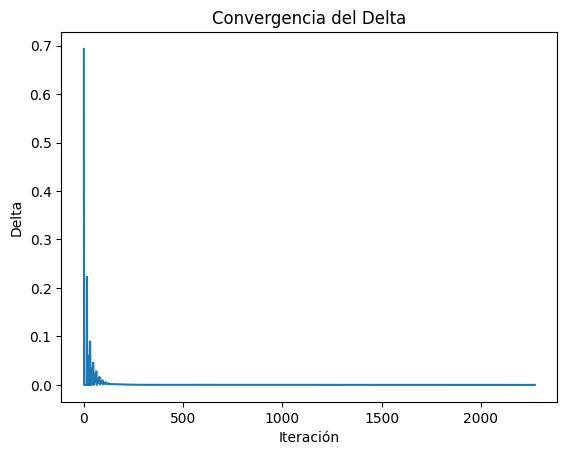

In [17]:
# Generar secuencia de vectores para la animación
vector_sequence, deltas = evaluar_politica(scene, rnd_policy)

# Crear un conjunto de matrices desde vector_sequence
data = [vector.reshape(4, 4) for vector in vector_sequence]
print(data[0], data[-1])

# Show all deltas
plt.plot(np.log1p(deltas))
plt.xlabel("Iteración")
plt.ylabel("Delta")
plt.title("Convergencia del Delta")
plt.show()

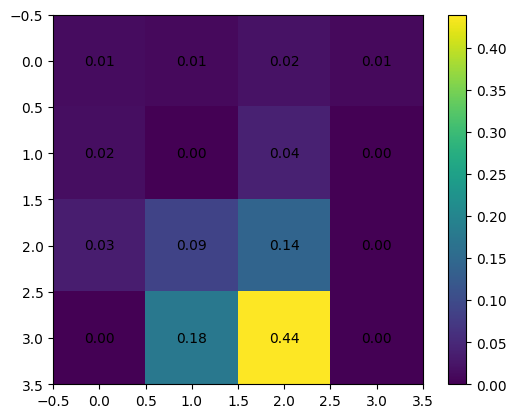

In [18]:
# Simular vector_sequence
# data = [np.random.rand(4, 4) for _ in range(10)]  # 10 matrices aleatorias 4x4

# Configurar la figura
fig, ax = plt.subplots()
cax = ax.imshow(data[0], cmap='viridis', vmin=np.min(data), vmax=np.max(data))
plt.colorbar(cax, ax=ax)

# Añadir etiquetas numéricas iniciales
texts = []
for i in range(4):
    for j in range(4):
        text = ax.text(j, i, f"{data[0][i, j]:.2f}", ha="center", va="center", color="black")
        texts.append(text)

# Función de actualización para la animación
def update(frame):
    # print(f"Frame {frame}: {data[frame]}")  # Impresión del frame actual
    cax.set_array(data[frame])
    for i in range(4):
        for j in range(4):
            texts[i * 4 + j].set_text(f"{data[frame][i, j]:.2f}")
    return cax, *texts

# Crear la animación
ani = FuncAnimation(fig, update, frames=len(data), interval=500, blit=True)

# Mostrar la animación en el notebook
HTML(ani.to_jshtml())




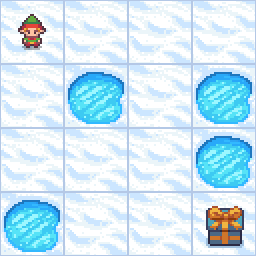

In [19]:
from IPython.display import Image, display

# Ruta al GIF local
gif_path = "frozen_lake.gif"

# Mostrar el GIF
display(Image(filename=gif_path))

In [20]:
vector_sequence = []
    # [0 ][1 ][2 ][3 ]
    # [4 ][5 ][6 ][7 ]
    # [8 ][9 ][10][11]
    # [12][13][14][15]

In [2]:

colors = {1, 2, 4}
if 3 in colors:
    print(f'{3=}')
else:
    print(f'{2=}')
    
    
    


2=2
